# --------------------------
✅ Step 1: Install Required Libraries
# --------------------------

In [ ]:
!pip install decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 71.1 MB/s eta 0:00:00


In [ ]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

In [ ]:
# Load feature extractor and pretrained model
feature_extractor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

#  Prepares (resizes, normalizes) video frames for the model.
# This is the pretrained ViViT model, already trained on the Kinetics-400 dataset.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

# --------------------------
✅ Step 3: Dataset
# --------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Path to the zip file in Drive
zip_path = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/dataset/Sexual_Harassment_Dataset.zip"

# Unzip it to /content/
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/Sexual_Harassment_Dataset")

# Set dataset path
dataset_path = "/content/Sexual_Harassment_Dataset"

In [ ]:
import os

# List top-level files/folders
print(os.listdir("/content/Sexual_Harassment_Dataset"))

# If it's nested, explore further:
for root, dirs, files in os.walk("/content/Sexual_Harassment_Dataset"):
    print("Root:", root)
    print("Dirs:", dirs)
    print("Files:", files[:5])  # just print the first 5 files
    print("===")

['Sexual_Harassment_Dataset']
Root: /content/Sexual_Harassment_Dataset
Dirs: ['Sexual_Harassment_Dataset']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset
Dirs: ['test', 'train']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test
Dirs: ['Harassment', 'Non_Harassment']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test/Harassment
Dirs: []
Files: ['haras_52.mp4', 'haras_234.mp4', 'haras_212.mp4', 'haras_204.mp4', 'haras_260.mp4']
===
Root: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test/Non_Harassment
Dirs: []
Files: ['no_haras_249.mp4', 'no_haras_157.mp4', 'no_haras_309.mp4', 'no_haras_143.mp4', 'no_haras_125.mp4']
===
Root: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/train
Dirs: ['Harassment', 'Non_Harassment']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/train/Harassment
Dirs: []
Files: ['haras_110.mp4', 'haras_19

In [ ]:
import os
from decord import VideoReader, cpu

dataset_path = "/content/Sexual_Harassment_Dataset/"

def count_unreadable_videos(root_dir):
    unreadable = []
    total = 0

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(".mp4"):
                total += 1
                video_path = os.path.join(root, file)

                try:
                    vr = VideoReader(video_path, ctx=cpu(0))
                    if len(vr) == 0:
                        unreadable.append(video_path)
                except:
                    unreadable.append(video_path)

    print(f"📦 Total videos found: {total}")
    print(f"❌ Unreadable videos: {len(unreadable)}\n")

    if unreadable:
        print("List of unreadable videos:")
        for path in unreadable:
            print(path)

count_unreadable_videos(dataset_path)

📦 Total videos found: 600
❌ Unreadable videos: 0



In [ ]:
import os

dataset_path_updated = "/content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset"

def count_videos_in_classes(root_dir):
    class_counts = {}
    for split_dir_name in os.listdir(root_dir):
        split_dir_path = os.path.join(root_dir, split_dir_name)
        if os.path.isdir(split_dir_path):
            for class_name in os.listdir(split_dir_path):
                class_dir = os.path.join(split_dir_path, class_name)
                if os.path.isdir(class_dir):
                    if class_name not in class_counts:
                        class_counts[class_name] = 0
                    video_count = 0
                    for root, dirs, files in os.walk(class_dir):
                        for file in files:
                            if file.lower().endswith(".mp4"):
                                video_count += 1
                    class_counts[class_name] += video_count
    return class_counts

class_video_counts = count_videos_in_classes(dataset_path_updated)

print("Video counts per class:")
for class_name, count in class_video_counts.items():
    print(f"- {class_name}: {count}")

Video counts per class:
- Harassment: 282
- Non_Harassment: 318


In [ ]:
import os
from decord import VideoReader, cpu

def get_video_paths_labels(split_dir, label_map):
    video_paths = []
    labels = []
    unreadable_videos_count = 0

    for cls in label_map:
        cls_folder = os.path.join(split_dir, cls)

        if not os.path.isdir(cls_folder):
            print(f"Warning: Class folder not found: {cls_folder}. Skipping.")
            continue

        for fname in os.listdir(cls_folder):
            if fname.lower().endswith('.mp4'):
                video_path = os.path.join(cls_folder, fname)

                try:
                    vr = VideoReader(video_path, ctx=cpu(0))
                    _ = len(vr)

                    video_paths.append(video_path)
                    labels.append(label_map[cls])

                except Exception as e:
                    print(f"Warning: Could not read video {video_path}. Skipping. Error: {e}")
                    unreadable_videos_count += 1

    print(f"\n[{os.path.basename(split_dir)}] Unreadable videos skipped: {unreadable_videos_count}")
    return video_paths, labels


def load_dataset(base_dataset_dir):
    label_map = {'Non_Harassment': 0, 'Harassment': 1}

    train_dir = os.path.join(base_dataset_dir, 'train')
    test_dir = os.path.join(base_dataset_dir, 'test')

    print("Loading TRAIN data...")
    train_paths, train_labels = get_video_paths_labels(train_dir, label_map)

    print("\nLoading TEST data...")
    test_paths, test_labels = get_video_paths_labels(test_dir, label_map)

    return train_paths, train_labels, test_paths, test_labels, label_map


# مسیر (path)
base_dataset_dir = "/content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset"

train_paths, train_labels, test_paths, test_labels, label_map = load_dataset(base_dataset_dir)

# Summary
print("\n===== DATA SUMMARY =====")
print(f"Train videos: {len(train_paths)}")
print(f"Train labels: {len(train_labels)}")
print(f"Test videos: {len(test_paths)}")
print(f"Test labels: {len(test_labels)}")
print(f"Label mapping: {label_map}")

# Sanity check
print("\nFirst 3 TRAIN samples:")
for i in range(min(3, len(train_paths))):
    print(f"Path: {train_paths[i]}, Label: {train_labels[i]}")

print("\nFirst 3 TEST samples:")
for i in range(min(3, len(test_paths))):
    print(f"Path: {test_paths[i]}, Label: {test_labels[i]}")

Loading TRAIN data...

[train] Unreadable videos skipped: 0

Loading TEST data...

[test] Unreadable videos skipped: 0

===== DATA SUMMARY =====
Train videos: 419
Train labels: 419
Test videos: 181
Test labels: 181
Label mapping: {'Non_Harassment': 0, 'Harassment': 1}

First 3 TRAIN samples:
Path: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/train/Non_Harassment/no_haras_83.mp4, Label: 0
Path: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/train/Non_Harassment/no_haras_214.mp4, Label: 0
Path: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/train/Non_Harassment/no_haras_169.mp4, Label: 0

First 3 TEST samples:
Path: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test/Non_Harassment/no_haras_249.mp4, Label: 0
Path: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test/Non_Harassment/no_haras_157.mp4, Label: 0
Path: /content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test/Non_Harassment/no_haras_309.mp4, Label: 

# ---------------------
Stap 4: Dataset Loader
# ---------------------

In [ ]:
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import numpy as np
from torchvision import transforms

class HarassmentDataset(Dataset):
    def __init__(self, video_paths, labels, feature_extractor, num_frames=16, is_train=True):
        self.video_paths = video_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.num_frames = num_frames
        self.is_train = is_train

        # Training augmentation
        self.train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomRotation(5),
            transforms.ToTensor()
        ])

        # Validation / Test transform (deterministic)
        self.val_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        vr = VideoReader(self.video_paths[idx], ctx=cpu(0))
        total_frames = len(vr)

        indices = np.linspace(
            0, total_frames - 1, min(self.num_frames, total_frames)
        ).astype(int)

        frames = vr.get_batch(indices).asnumpy()

        if self.is_train:
            frames = [self.train_transform(frame) for frame in frames]
        else:
            frames = [self.val_transform(frame) for frame in frames]

        frames = [(frame.permute(1, 2, 0).numpy() * 255).astype(np.uint8) for frame in frames]

        inputs = self.feature_extractor(frames, return_tensors="pt")
        return inputs["pixel_values"].squeeze(0), self.labels[idx]

In [ ]:
from torch.utils.data import DataLoader

train_dataset = HarassmentDataset(
    train_paths, train_labels, feature_extractor, is_train=True
)

val_dataset = HarassmentDataset(
    test_paths, test_labels, feature_extractor, is_train=False
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2)

In [ ]:
for i, (pixel_values, labels) in enumerate(train_loader):
    print(f"Batch {i+1}")
    print("Pixel values shape:", pixel_values.shape)  # Should be (B, T, C, H, W) or (B, 3, 16, 224, 224) after permute
    print("Labels:", labels)
    if i == 1:  # print only first 2 batches
        break

Batch 1
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([1, 0])
Batch 2
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([1, 0])


In [ ]:
for i, (pixel_values, labels) in enumerate(val_loader):
    print(f"Validation Batch {i+1}")
    print("Pixel values shape:", pixel_values.shape)
    print("Labels:", labels)
    if i == 1:
        break

Validation Batch 1
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 0])
Validation Batch 2
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 0])


In [ ]:
print(pixel_values.shape)

torch.Size([2, 16, 3, 224, 224])


In [ ]:
print(f"Number of training videos: {len(train_dataset)}")
print(f"Number of validation videos: {len(val_dataset)}")

Number of training videos: 419
Number of validation videos: 181


In [ ]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 210
Number of validation batches: 91


In [ ]:
print(f"Number of classes: {len(label_map)}")
print(f"Label map: {label_map}")

Number of classes: 2
Label map: {'Non_Harassment': 0, 'Harassment': 1}


# ---------
Step 5: Adjust Model Output Layer
# ---------

In [ ]:
import torch.nn as nn

num_classes = len(label_map)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.config.num_labels = num_classes

In [ ]:
print(f"Model name: {model.config._name_or_path}")

Model name: MCG-NJU/videomae-base-finetuned-kinetics


# ---------------
Step 7: Train the Dataset
# ---------------

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report
from tqdm import tqdm
import os

# =====================
# Device
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"✅ Using device: {device}")

# =====================
# Loss & Optimizer
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3)

# =====================
# Settings
# =====================
num_epochs = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

idx_to_class = {v: k for k, v in label_map.items()}

# =====================
# Paths
# =====================
checkpoint_dir = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints/New"
os.makedirs(checkpoint_dir, exist_ok=True)

latest_ckpt = os.path.join(checkpoint_dir, "last_checkpoint.pth")
best_model_path = os.path.join(checkpoint_dir, "best_model.pth")

# =====================
# Resume Training
# =====================
start_epoch = 0
best_val_loss = float("inf")

if os.path.exists(latest_ckpt):
    checkpoint = torch.load(latest_ckpt, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])

    print(f"🔁 Resumed from epoch {start_epoch}")

# =====================
# Training Loop
# =====================
for epoch in range(start_epoch, num_epochs):
    print(f"\n🎯 Epoch {epoch+1}/{num_epochs}")

    # ---- TRAIN ----
    model.train()
    running_loss, correct, total = 0, 0, 0

    for pixel_values, labels in tqdm(train_loader, desc="Training"):
        pixel_values, labels = pixel_values.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, pred = torch.max(logits, 1)

        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---- VALIDATION ----
    model.eval()
    val_loss_total, correct, total = 0, 0, 0
    true_labels, pred_labels = [], []

    with torch.no_grad():
        for pixel_values, labels in tqdm(val_loader, desc="Validating"):
            pixel_values, labels = pixel_values.to(device), labels.to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs

            loss = criterion(logits, labels)
            val_loss_total += loss.item()

            _, pred = torch.max(logits, 1)

            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(pred.cpu().numpy())

    val_loss = val_loss_total / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"📉 Train Loss: {train_loss:.4f} | 📈 Val Loss: {val_loss:.4f}")
    print(f"✅ Train Acc: {train_acc:.2f}% | ✅ Val Acc: {val_acc:.2f}%")

    # ---- Scheduler ----
    scheduler.step(val_loss)
    print(f"📉 LR: {optimizer.param_groups[0]['lr']:.8f}")

    # ---- Save BEST MODEL ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("🌟 Best model updated!")

    # ---- Save MODEL ONLY (EVERY EPOCH) ----
    model_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch+1}.pth")
    torch.save(model.state_dict(), model_path)

    # ---- Save LAST CHECKPOINT (for resume) ----
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "best_val_loss": best_val_loss
    }, latest_ckpt)

    print(f"💾 Saved model_epoch_{epoch+1}.pth + updated last checkpoint")

    # ---- Classification Report ----
    print("\n🧾 Classification Report:")
    print(classification_report(
        [idx_to_class[i] for i in true_labels],
        [idx_to_class[i] for i in pred_labels],
        digits=3,
        zero_division=0
    ))

print("\n🎯 Training Finished!")

✅ Using device: cuda

🎯 Epoch 1/20


Validating: 100%|██████████| 91/91 [02:07<00:00,  1.40s/it]


📉 Train Loss: 0.5836 | 📈 Val Loss: 0.5113
✅ Train Acc: 67.78% | ✅ Val Acc: 80.11%
📉 LR: 0.00001000
🌟 Best model updated!
💾 Saved model_epoch_1.pth + updated last checkpoint

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.802     0.765     0.783        85
Non_Harassment      0.800     0.833     0.816        96

      accuracy                          0.801       181
     macro avg      0.801     0.799     0.800       181
  weighted avg      0.801     0.801     0.801       181


🎯 Epoch 2/20


Validating: 100%|██████████| 91/91 [02:04<00:00,  1.37s/it]


📉 Train Loss: 0.2756 | 📈 Val Loss: 0.4309
✅ Train Acc: 89.74% | ✅ Val Acc: 80.66%
📉 LR: 0.00001000
🌟 Best model updated!
💾 Saved model_epoch_2.pth + updated last checkpoint

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.903     0.659     0.762        85
Non_Harassment      0.756     0.938     0.837        96

      accuracy                          0.807       181
     macro avg      0.830     0.798     0.800       181
  weighted avg      0.825     0.807     0.802       181


🎯 Epoch 3/20


...

📉 Train Loss: 0.0007 | 📈 Val Loss: 0.2741
✅ Train Acc: 100.00% | ✅ Val Acc: 91.16%
📉 LR: 0.00000010
💾 Saved model_epoch_18.pth + updated last checkpoint

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.926     0.882     0.904        85
Non_Harassment      0.900     0.938     0.918        96

      accuracy                          0.912       181
     macro avg      0.913     0.910     0.911       181
  weighted avg      0.912     0.912     0.911       181


🎯 Epoch 19/20


Validating: 100%|██████████| 91/91 [02:04<00:00,  1.37s/it]


📉 Train Loss: 0.0006 | 📈 Val Loss: 0.2740
✅ Train Acc: 100.00% | ✅ Val Acc: 91.16%
📉 LR: 0.00000001
💾 Saved model_epoch_19.pth + updated last checkpoint

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.926     0.882     0.904        85
Non_Harassment      0.900     0.938     0.918        96

      accuracy                          0.912       181
     macro avg      0.913     0.910     0.911       181
  weighted avg      0.912     0.912     0.911       181


🎯 Epoch 20/20


Validating: 100%|██████████| 91/91 [02:05<00:00,  1.38s/it]


📉 Train Loss: 0.0007 | 📈 Val Loss: 0.2740
✅ Train Acc: 100.00% | ✅ Val Acc: 91.16%
📉 LR: 0.00000001
💾 Saved model_epoch_20.pth + updated last checkpoint

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.926     0.882     0.904        85
Non_Harassment      0.900     0.938     0.918        96

      accuracy                          0.912       181
     macro avg      0.913     0.910     0.911       181
  weighted avg      0.912     0.912     0.911       181


🎯 Training Finished!


In [ ]:
import torch
import os
import pandas as pd

# =====================
# Paths
# =====================
checkpoint_dir = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints/New"
latest_ckpt = os.path.join(checkpoint_dir, "last_checkpoint.pth")

# =====================
# Load Checkpoint
# =====================
if os.path.exists(latest_ckpt):
    print(f"✅ Loading checkpoint: {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location='cpu')  # Use CPU for safety

    start_epoch = checkpoint.get("epoch", 0) + 1
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])

    print(f"\n📊 Training History Summary")
    print(f"   Best Validation Loss : {best_val_loss:.4f}")
    print(f"   Total epochs recorded: {len(train_losses)}\n")

    # =====================
    # Print Detailed History Table
    # =====================
    print("Epoch-wise Training History:")
    print("-" * 85)
    print(f"{'Epoch':<6} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Best?':<8}")
    print("-" * 85)

    best_epoch = -1
    best_loss = float("inf")

    for epoch in range(len(train_losses)):
        is_best = val_losses[epoch] < best_loss
        if is_best:
            best_loss = val_losses[epoch]
            best_epoch = epoch + 1

        print(f"{epoch+1:<6} "
              f"{train_losses[epoch]:<12.4f} "
              f"{val_losses[epoch]:<12.4f} "
              f"{train_accuracies[epoch]:<12.2f}% "
              f"{val_accuracies[epoch]:<12.2f}% "
              f"{'★ Best' if is_best else '':<8}")

    print("-" * 85)
    print(f"→ Best model was at Epoch {best_epoch} with Val Loss: {best_loss:.4f}")

    # =====================
    # Optional: Save as CSV for better viewing
    # =====================
    history_dict = {
        'Epoch': list(range(1, len(train_losses) + 1)),
        'Train_Loss': train_losses,
        'Val_Loss': val_losses,
        'Train_Acc': train_accuracies,
        'Val_Acc': val_accuracies
    }

    df = pd.DataFrame(history_dict)
    csv_path = os.path.join(checkpoint_dir, "training_history.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n💾 Training history also saved as CSV: {csv_path}")

else:
    print(f"❌ Checkpoint file not found: {latest_ckpt}")

✅ Loading checkpoint: /content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints/New/last_checkpoint.pth

📊 Training History Summary
   Best Validation Loss : 0.2601
   Total epochs recorded: 20

Epoch-wise Training History:
-------------------------------------------------------------------------------------
Epoch  Train Loss   Val Loss     Train Acc    Val Acc      Best?   
-------------------------------------------------------------------------------------
1      0.5836       0.5113       67.78       % 80.11       % ★ Best  
2      0.2756       0.4309       89.74       % 80.66       % ★ Best  
3      0.1006       0.3204       97.61       % 88.95       % ★ Best  
4      0.0378       0.2891       99.76       % 88.95       % ★ Best  
5      0.0324       0.2767       99.05       % 90.06       % ★ Best  
6      0.0076       0.2663       100.00      % 91.71       % ★ Best  
7      0.0030       0.2601       100.00      % 91.71       % ★ Best  
8      0.0025       0.2767       100.00 

In [ ]:
best_model = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints/New/best_model.pth"

In [ ]:
# Make sure num_classes is still set correctly
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.load_state_dict(torch.load(best_model))
model.eval()
model.to(device)

VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
    

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation function
def evaluate(model, dataloader, label_map, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    val_loss = 0
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for pixel_values, labels in dataloader:
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())

    avg_loss = val_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, pred_labels)

    # Convert index to class names
    idx_to_class = {v: k for k, v in label_map.items()}
    true_class_names = [idx_to_class[i] for i in true_labels]
    pred_class_names = [idx_to_class[i] for i in pred_labels]

    # Classification report
    report = classification_report(true_class_names, pred_class_names, digits=3)

    return avg_loss, accuracy, report, true_class_names, pred_class_names

Validation Accuracy: 91.71%
💾 Validation Loss: 0.2601

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.907     0.918     0.912        85
Non_Harassment      0.926     0.917     0.921        96

      accuracy                          0.917       181
     macro avg      0.917     0.917     0.917       181
  weighted avg      0.917     0.917     0.917       181



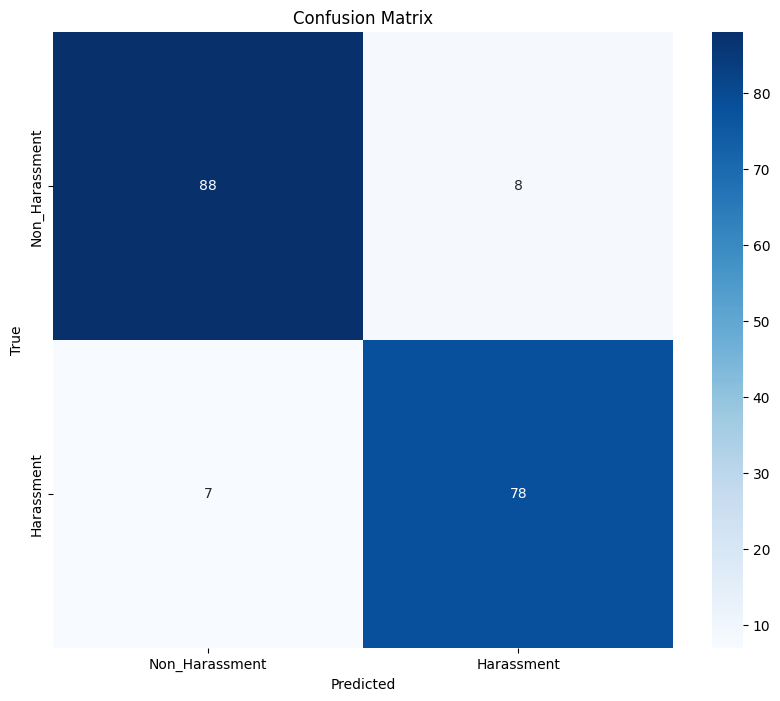

In [ ]:
# Load best model
model.load_state_dict(torch.load(best_model))
model.to(device)
model.eval()

# Run evaluation
avg_test_loss, test_acc, report, true_class_names, pred_class_names = evaluate(model, val_loader, label_map, device)

# Print results
print(f"Validation Accuracy: {test_acc * 100:.2f}%")
print(f"💾 Validation Loss: {avg_test_loss:.4f}")
print("\n🧾 Classification Report:")
print(report)

# Plot Confusion Matrix
idx_to_class = {v: k for k, v in label_map.items()}
class_names = list(idx_to_class.values())

cm = confusion_matrix(true_class_names, pred_class_names, labels=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
best_epoch

7

Validation Accuracy: 91.71%
💾 Validation Loss: 0.2601

🧾 Classification Report:
                precision    recall  f1-score   support

    Harassment      0.907     0.918     0.912        85
Non_Harassment      0.926     0.917     0.921        96

      accuracy                          0.917       181
     macro avg      0.917     0.917     0.917       181
  weighted avg      0.917     0.917     0.917       181



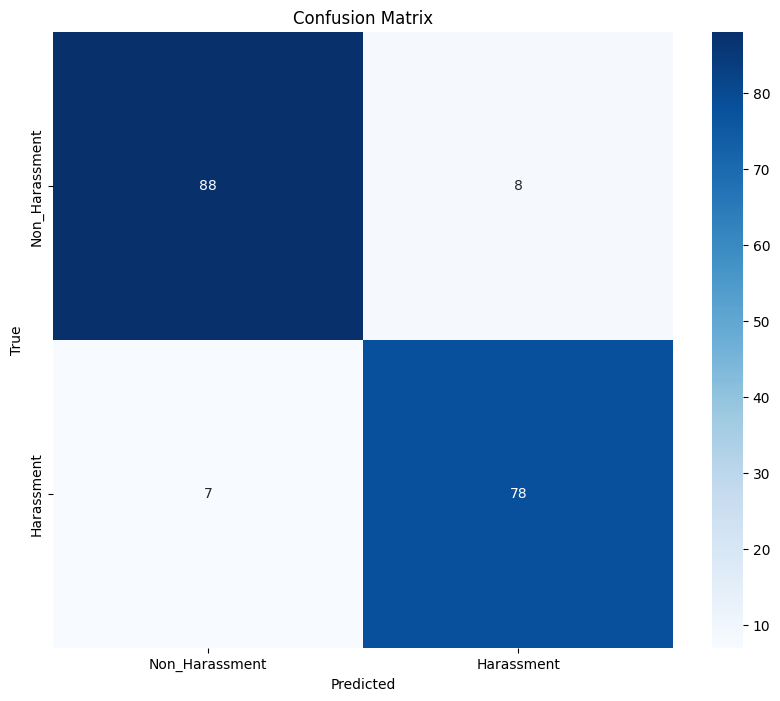

In [ ]:
best_model = f"/content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints/New/model_epoch_7.pth"

# Load best model
model.load_state_dict(torch.load(best_model))
model.to(device)
model.eval()

# Run evaluation
avg_test_loss, test_acc, report, true_class_names, pred_class_names = evaluate(model, val_loader, label_map, device)

# Print results
print(f"Validation Accuracy: {test_acc * 100:.2f}%")
print(f"💾 Validation Loss: {avg_test_loss:.4f}")
print("\n🧾 Classification Report:")
print(report)

# Plot Confusion Matrix
idx_to_class = {v: k for k, v in label_map.items()}
class_names = list(idx_to_class.values())

cm = confusion_matrix(true_class_names, pred_class_names, labels=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

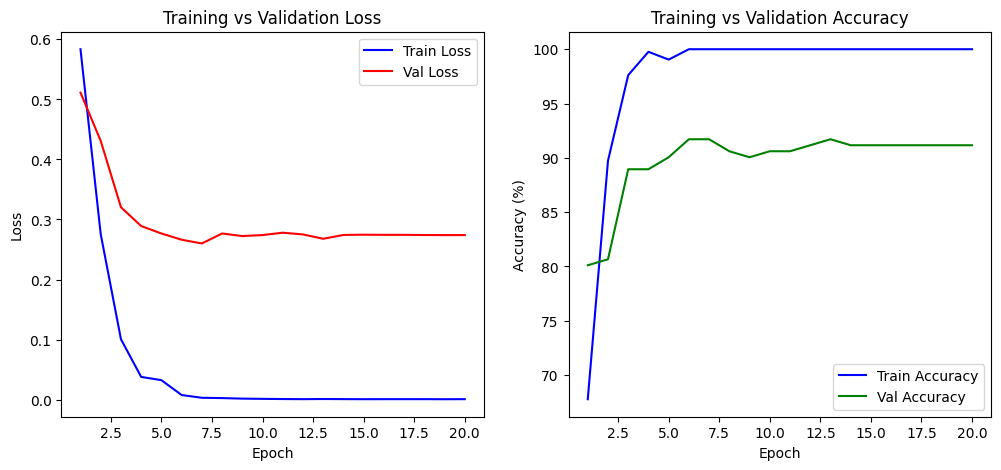

In [ ]:
# =====================
# Plot Loss & Accuracy Curves
# =====================
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# ----- Loss Curve -----
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# ----- Accuracy Curve -----
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'g-', label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def evaluate_and_plot_roc(y_true, y_score, model_name="Classifier Model"):
    """
    Calculates ROC curve points (FPR, TPR), AUC, and plots the ROC curve.

    Args:
        y_true (array-like): True binary labels (0 or 1).
        y_score (array-like): Target scores (e.g., predicted probabilities of class 1).
        model_name (str): The name of the model for the plot title and legend.

    Returns:
        tuple: (fpr, tpr, roc_auc)
            fpr (array): False Positive Rates
            tpr (array): True Positive Rates
            roc_auc (float): Area Under the Curve
    """
    # 1. Calculate ROC Curve Points
    fpr, tpr, _ = roc_curve(y_true, y_score)

    # 2. Calculate Area Under the Curve (AUC)
    roc_auc = roc_auc_score(y_true, y_score)

    print(f"--- {model_name} Evaluation ---")
    print(f"Area Under the Curve (AUC): {roc_auc:.4f}")

    # 3. Plotting the ROC Curve
    plt.figure(figsize=(8, 6))

    # Plot the ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve for {model_name} (AUC = {roc_auc:.4f})')

    # Plot the 45-degree line (random classifier benchmark)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Guess (AUC = 0.5)')

    # Set plot labels and title
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR) / Recall')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show() # Display the plot

    return fpr, tpr, roc_auc

--- Video Classification Model Evaluation ---
Area Under the Curve (AUC): 0.9533


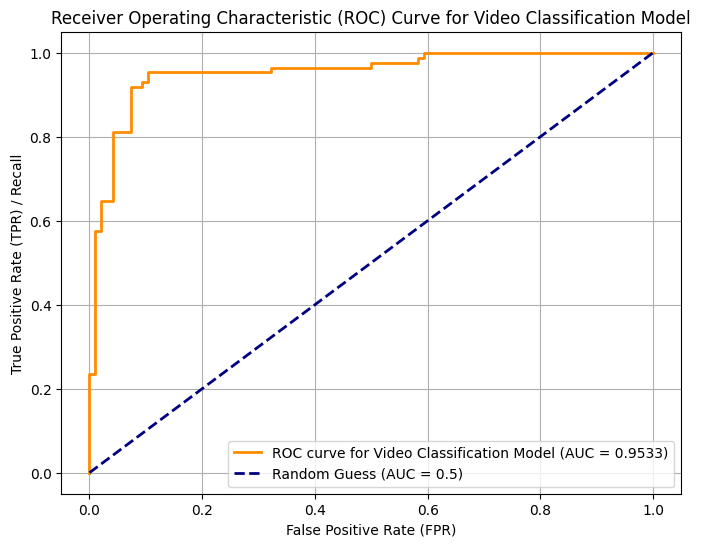

In [ ]:
# Perform evaluation to get true_class_names and all_probs
# This code is adapted from the evaluation cell (u4Vc3micGXvn) to make variables available

# Load best model if not already loaded and moved to device
# Assuming model and device are already defined and model is loaded and moved to device in previous cells
# model.load_state_dict(torch.load(best_model)) # Avoid reloading if already done
# model.to(device) # Avoid moving if already done
model.eval() # Ensure model is in evaluation mode

true_labels = []
all_probs = []

# Re-run a simplified evaluation loop to get probabilities and true labels
with torch.no_grad():
    for pixel_values, labels in val_loader:
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=pixel_values)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1) # Calculate probabilities
        all_probs.extend(probs.cpu().numpy()) # Store probabilities

        true_labels.extend(labels.cpu().numpy())

# Convert index to class names and binary labels
idx_to_class = {v: k for k, v in label_map.items()}
true_class_names = [idx_to_class[i] for i in true_labels]
all_probs = np.array(all_probs)


# Assuming binary classification with 'No_Harassment' as negative (0) and 'Harassment' as positive (1)
# We need the probabilities of the positive class (Harassment, which is index 1)
harassment_probs = all_probs[:, label_map['Harassment']]
true_labels_binary = [label_map[name] for name in true_class_names] # Convert class names back to binary labels

y_test = true_labels_binary
y_preds_proba = harassment_probs

# Call the function to plot the ROC curve
# Assuming evaluate_and_plot_roc function is defined in a previous cell (IZ9UfHWQbVQB)
fpr, tpr, auc = evaluate_and_plot_roc(y_test, y_preds_proba, model_name="Video Classification Model")

In [ ]:
def predict_video(video_path, model, feature_extractor, label_map, num_frames=16):
    # Load video frames
    vr = VideoReader(video_path, ctx=cpu(0))
    total_frames = len(vr)
    indices = np.linspace(0, total_frames - 1, min(num_frames, total_frames)).astype(int)
    frames = vr.get_batch(indices).asnumpy()

    # Preprocess
    inputs = feature_extractor(list(frames), return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    # Inference
    with torch.no_grad():
        outputs = model(pixel_values)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred_class_idx = torch.argmax(probs, dim=1).item()

    # Map index to class name
    class_name = [k for k, v in label_map.items() if v == pred_class_idx][0]
    confidence = probs[0][pred_class_idx].item()
    return class_name, confidence

In [ ]:
video_path = "/content/Sexual_Harassment_Dataset/Sexual_Harassment_Dataset/test/Harassment/haras_10.mp4"  # <-- change this to your actual file
pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)
print(f"Predicted: {pred_class} ({confidence*100:.1f}%)")

Predicted: Harassment (65.5%)


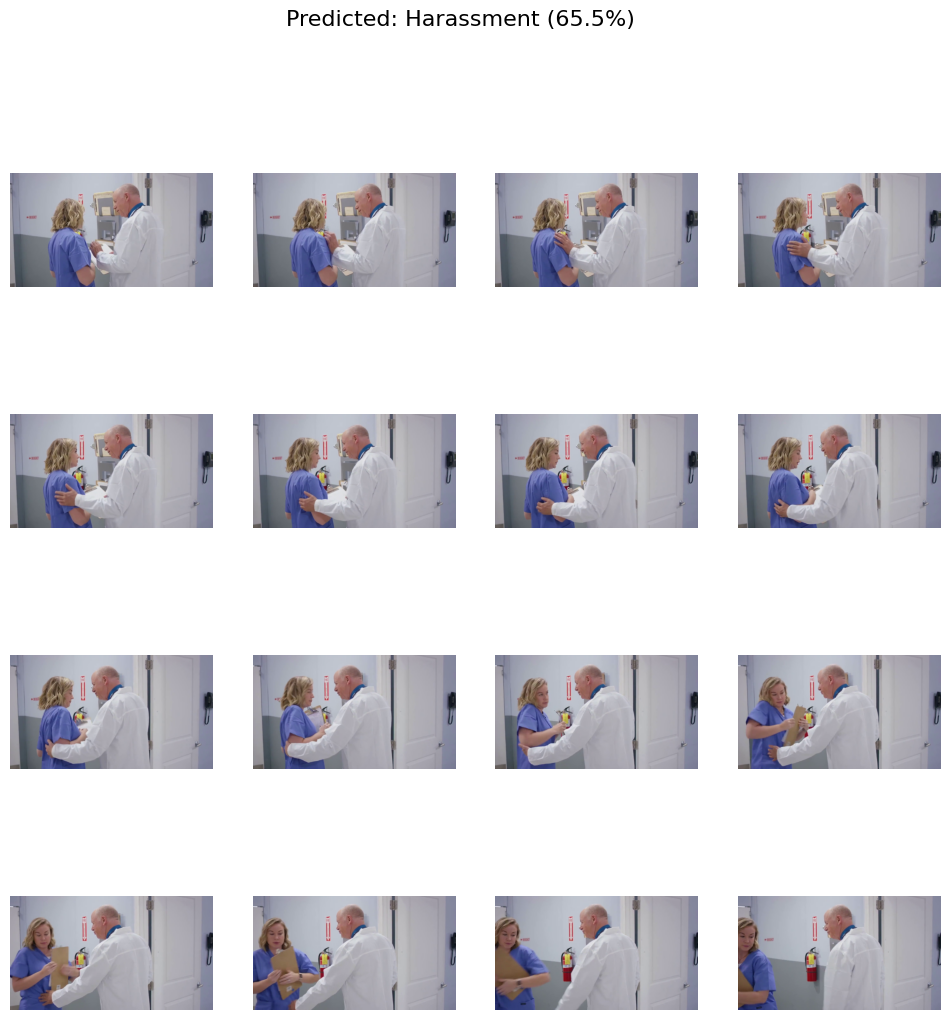

In [ ]:
# Re-run the prediction to ensure pred_class and confidence are defined
pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)

vr = VideoReader(video_path, ctx=cpu(0))
frames = vr.get_batch(np.linspace(0, len(vr)-1, 16).astype(int)).asnumpy()

import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(frames[i])
    ax.axis('off')
plt.suptitle(f"Predicted: {pred_class} ({confidence*100:.1f}%)", fontsize=16)
plt.show()